<h2><b>Parameter Initialization Methods</b></h2>

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import h5py
import time
import sklearn
import sklearn.datasets

<h3><b>A Deep Feed Forward Neural Network</b></h3>

In [56]:
def layer_sizes(X, Y, num_hidden_units):
    
    num_input_units = [X.shape[0]]
    num_output_units = [Y.shape[0]]
    num_hidden_units = list(num_hidden_units)
    
    num_layer_units = list(num_input_units + num_hidden_units + num_output_units)
    
    return num_layer_units


# implement parameter initialization function using He method
def initialize_parameters_he(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * np.sqrt(2 / num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters


def initialize_parameters_deep(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) / np.sqrt(num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using Xavier method
def initialize_parameters_xavier(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * np.sqrt(1 / num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using big random variables
def initialize_parameters_random1(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * 10
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using small random variables
def initialize_parameters_random2(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * 0.01
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using small random variables for both W and b
def initialize_parameters_random3(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * 0.01
        parameters[f"b{l}"] = np.random.randn(num_layer_units[l], 1) * 0.01
        
    return parameters

# implement parameter initialization function using uniform random variables
def initialize_parameters_random4(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.rand(num_layer_units[l], num_layer_units[l-1]) * 0.01
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters


def sigmoid(Z):

    A = 1 / (1 + np.exp(-Z))
    cache = Z

    return A, cache


def relu(Z):

    A = np.maximum(0, Z)
    cache = Z
    
    return A, cache
  

def derivative_sigmoid(dA, cache):

    Z = cache
    A = 1 / (1 + np.exp(-Z))
    dZ = dA * A * (1 - A)
    assert (dZ.shape == Z.shape)
    
    return dZ


def derivative_relu(dA, cache):
    
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ


def helper_forward1(A_prev, W, b):

    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)

    return Z, cache


def helper_forward2(A_prev, W, b, activation):

    if activation == "relu":

        Z, linear_cache = helper_forward1(A_prev=A_prev, W=W, b=b)
        A, activation_cache = relu(Z=Z)
    elif activation == "sigmoid":

        Z, linear_cache = helper_forward1(A_prev=A_prev, W=W, b=b)
        A, activation_cache = sigmoid(Z=Z)
        
    cache = (linear_cache, activation_cache)

    return A, cache


def forward_propagation(X, parameters, hidden_activation, output_activation):

    caches = []
    A = X
    num_layers = len(parameters) // 2


    for l in range(1, num_layers):
        A_prev = A
        A, cache = helper_forward2(
            A_prev=A_prev, 
            W=parameters[f"W{l}"], 
            b=parameters[f"b{l}"], 
            activation=hidden_activation
        )
        caches.append(cache)

    A, cache = helper_forward2(
        A_prev=A, 
        W=parameters[f"W{num_layers}"], 
        b=parameters[f"b{num_layers}"], 
        activation=output_activation
    )
    caches.append(cache) 
    
    return A, caches


def compute_cost(A, Y, sigma):

    m = Y.shape[1]

    cost = - np.sum(np.multiply(Y, np.log(A+sigma)) + np.multiply(1 - Y, np.log(1 - A+sigma))) / m
    cost = np.squeeze(cost)

    return cost


def helper_backward1(dZ, cache):

    A_prev, W, b = cache
    m = A_prev.shape[1]
    
    dW = np.dot(dZ, A_prev.T) / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db


def helper_backward2(dA, cache, activation):

    linear_cache, activation_cache = cache

    if activation == "relu":

        dZ = derivative_relu(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)
        
    elif activation == "sigmoid":

        dZ = derivative_sigmoid(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)

    return dA_prev, dW, db


def backward_propagation(A, Y, caches, hidden_activation, output_activation):

    grads = {}
    L = len(caches)
    Y = Y.reshape(A.shape)

    dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))

    current_cache = caches[-1]
    dA_prev, dW, db = helper_backward2(dA=dA, cache=current_cache, activation=output_activation)
    grads[f"dW{L}"] = dW
    grads[f"db{L}"] = db
    grads[f"dA{L-1}"] = dA_prev

    
    for l in reversed(range(L - 1)):

        current_cache = caches[l]
        dA_prev, dW, db = helper_backward2(dA=grads[f"dA{l+1}"], cache=current_cache, activation=hidden_activation)
        grads[f"dW{l+1}"] = dW
        grads[f"db{l+1}"] = db
        grads[f"dA{l}"] = dA_prev
         

    return grads


def update_parameters(parameters, grads, learning_rate):

    parameters_ = copy.deepcopy(parameters)
    L = len(parameters_) // 2

    for l in range(L):
        
        parameters_[f"W{l+1}"] -= learning_rate * grads[f"dW{l+1}"]
        parameters_[f"b{l+1}"] -= learning_rate * grads[f"db{l+1}"]

    return parameters_

def predict(X, parameters, hidden_activation, output_activation):
    
    predicted = np.zeros((1, X.shape[1]))
    
    probabilities, caches = forward_propagation(
        X=X, 
        parameters=parameters,
        hidden_activation=hidden_activation,
        output_activation=output_activation
    )
    
    predicted[0, :] = (probabilities > 0.5)

    return predicted


def accuracy(predicted, Y):
    
    accuracy = np.sum((predicted == Y) / Y.shape[1])
    
    return accuracy



def train(X_train, Y_train, X_test, Y_test, parameters, hidden_activation, output_activation, num_epochs, learning_rate, print_cost, epsilon, sigma):

    train_cost = []
    test_cost = []
    durations = []
    
    for i in range(1, num_epochs+1):
        tic = time.time()
        
        A, caches = forward_propagation(
            X=X_train, 
            parameters=parameters,
            hidden_activation=hidden_activation,
            output_activation=output_activation
        )
        cost = compute_cost(A=A, Y=Y_train, sigma=sigma)
        train_cost.append(cost)

        A_test, _ = forward_propagation(
            X=X_test, 
            parameters=parameters,
            hidden_activation=hidden_activation,
            output_activation=output_activation
        )
        cost_t = compute_cost(A=A_test, Y=Y_test, sigma=sigma)
        test_cost.append(cost_t)
        
        grads = backward_propagation(
            A=A, 
            Y=Y_train, 
            caches=caches, 
            hidden_activation=hidden_activation,
            output_activation=output_activation
        )
        parameters = update_parameters(
            parameters=parameters,
            grads=grads, 
            learning_rate=learning_rate
        )
        toc = time.time()
        durations.append(toc - tic)
        if print_cost and i % epsilon == 0:
            print(f"Epoch {i}; Cost: {cost}; Duration: {round(sum(durations[i-epsilon: i]), 3)} S")
        if i == num_epochs and i % epsilon != 0:
            print(f"Epoch {i}; Cost: {cost}; Duration: {round(toc - tic, 3)} S")
                
    
    train_predicted = predict(
        X=X_train, 
        parameters=parameters, 
        hidden_activation=hidden_activation,
        output_activation=output_activation
    )   
    train_accuracy = accuracy(predicted=train_predicted, Y=Y_train) 

    test_predicted = predict(
        X=X_test,
        parameters=parameters,
        hidden_activation=hidden_activation,
        output_activation=output_activation
    )   
    test_accuracy = accuracy(predicted=test_predicted, Y=Y_test)
    

    return (parameters, train_predicted, train_accuracy, train_cost, test_predicted, test_accuracy, test_cost)
    



def model(X_train, Y_train, X_test, Y_test, num_hidden_units, hidden_activation="relu", output_activation="sigmoid", init="he", num_epochs=10000, learning_rate=1e-4, print_cost=True, epsilon=1000, sigma=1e-12):

    
    num_layer_units = layer_sizes(X=X_train, Y=Y_train, num_hidden_units=num_hidden_units)

    if init == "he":
        parameters = initialize_parameters_he(num_layer_units=num_layer_units)
    elif init == "xavier":
        parameters = initialize_parameters_xavier(num_layer_units=num_layer_units)
    elif init == "big_random":
        parameters = initialize_parameters_random1(num_layer_units=num_layer_units)
    elif init == "small_random":
        parameters = initialize_parameters_random2(num_layer_units=num_layer_units)
    elif init == "wb_random":
        parameters = initialize_parameters_random3(num_layer_units=num_layer_units)
    elif init == "uniform_random":
        parameters = initialize_parameters_random4(num_layer_units=num_layer_units)
    elif init == "deep":
        parameters = initialize_parameters_deep(num_layer_units=num_layer_units)

    if print_cost:
        print("___"*33)
        print(f"NN_Model with {len(num_hidden_units)+1} layers; Number of Epochs: {num_epochs}; Learning Rate: {learning_rate}; Initialization Method: {init}")
        print("___"*33)
   
    
    train_params = train(X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test, 
                         parameters=parameters, hidden_activation=hidden_activation, 
                         output_activation=output_activation, num_epochs=num_epochs, 
                         learning_rate=learning_rate, print_cost=print_cost, epsilon=epsilon, sigma=sigma)
    

    parameters, train_predicted, train_accuracy, train_cost, test_predicted, test_accuracy, test_cost = train_params
 

    print("__"*20)
    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print("__"*20)
    
    plt.plot(train_cost, label="Train Cost")
    plt.plot(test_cost, label="Test Cost")
    plt.title("Epoch vs. Cost")
    plt.xlabel(f"Epoch Scaled by {epsilon}")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()
    
    return parameters
    

In [42]:
train_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_cat.h5", "r")
train_set_x_orig = np.array(train_dataset["train_set_x"][:])  # your train set features
train_set_y_orig = np.array(train_dataset["train_set_y"][:])  # your train set labels

test_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_cat.h5", "r")
test_set_x_orig = np.array(test_dataset["test_set_x"][:])  # your test set features
test_set_y_orig = np.array(test_dataset["test_set_y"][:])  # your test set labels

classes = np.array(test_dataset["list_classes"][:])  # the list of classes

train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))


train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
print(train_set_x_flatten.shape)
print(test_set_x_flatten.shape)

X_train = train_set_x_flatten / 255
Y_train = train_set_y_orig
X_test = test_set_x_flatten / 255
Y_test = test_set_y_orig
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


(12288, 209)
(12288, 50)
(12288, 209)
(1, 209)
(12288, 50)
(1, 50)


___________________________________________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: he
___________________________________________________________________________________________________
Epoch 400; Cost: 0.5923312558969223; Duration: 10.399 S
Epoch 800; Cost: 0.49463389985490136; Duration: 10.59 S
Epoch 1200; Cost: 0.4039387759245367; Duration: 10.498 S
Epoch 1600; Cost: 0.30167668193904246; Duration: 9.04 S
Epoch 2000; Cost: 0.21889853187752442; Duration: 8.959 S
Epoch 2400; Cost: 0.16526241686886525; Duration: 9.066 S
Epoch 2800; Cost: 0.1275835447692671; Duration: 8.823 S
Epoch 3200; Cost: 0.1007830333484682; Duration: 8.79 S
Epoch 3600; Cost: 0.07783609190491553; Duration: 8.94 S
Epoch 4000; Cost: 0.06418666529450875; Duration: 10.052 S
Epoch 4400; Cost: 0.05569276993502327; Duration: 10.427 S
Epoch 4800; Cost: 0.05027275382523235; Duration: 10.211 S
Epoch 5000; Cost: 0.0482

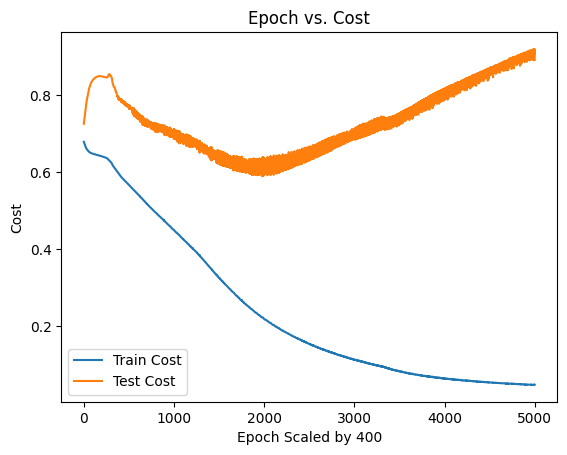

In [46]:
parameters = model(X_train, Y_train, X_test, Y_test, [20, 10, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
                   init="he", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6282782566444592; Duration: 11.082 S
Epoch 800; Cost: 0.605421631289871; Duration: 11.669 S
Epoch 1200; Cost: 0.5800060564153525; Duration: 10.436 S
Epoch 1600; Cost: 0.547737188685216; Duration: 10.407 S
Epoch 2000; Cost: 0.5049032237429557; Duration: 15.306 S
Epoch 2400; Cost: 0.4469221891579948; Duration: 12.058 S
Epoch 2800; Cost: 0.37347251196860287; Duration: 13.169 S
Epoch 3200; Cost: 0.2949725919631156; Duration: 11.829 S
Epoch 3600; Cost: 0.22437455196352438; Duration: 10.326 S
Epoch 4000; Cost: 0.16829776820474607; Duration: 9.799 S
Epoch 4400; Cost: 0.12719836969172268; Duration: 9.693 S
Epoch 4800; Cost: 0.09677482999891743; Duration: 10.318 S
Epoch 5000; Cost: 0

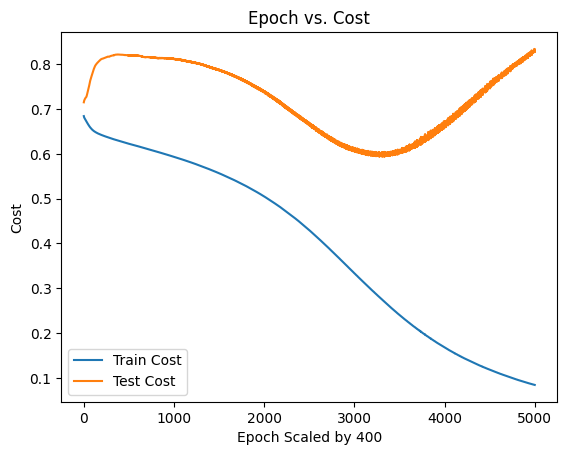

In [47]:
parameters = model(X_train, Y_train, X_test, Y_test, [20, 10, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
                   init="deep", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: xavier
___________________________________________________________________________________________________
Epoch 400; Cost: 0.5888115962233303; Duration: 7.406 S
Epoch 800; Cost: 0.5428451230464285; Duration: 7.458 S
Epoch 1200; Cost: 0.5007046546238427; Duration: 8.826 S
Epoch 1600; Cost: 0.4557400901903662; Duration: 8.482 S
Epoch 2000; Cost: 0.40576129342247336; Duration: 7.798 S
Epoch 2400; Cost: 0.3532565177240148; Duration: 8.668 S
Epoch 2800; Cost: 0.3024750786643261; Duration: 7.482 S
Epoch 3200; Cost: 0.25550653826472464; Duration: 7.651 S
Epoch 3600; Cost: 0.2135280710234269; Duration: 7.325 S
Epoch 4000; Cost: 0.17677294873182584; Duration: 7.207 S
Epoch 4400; Cost: 0.14562640921734465; Duration: 7.854 S
Epoch 4800; Cost: 0.11988955594906239; Duration: 8.557 S
Epoch 5000; Cost: 0.10896

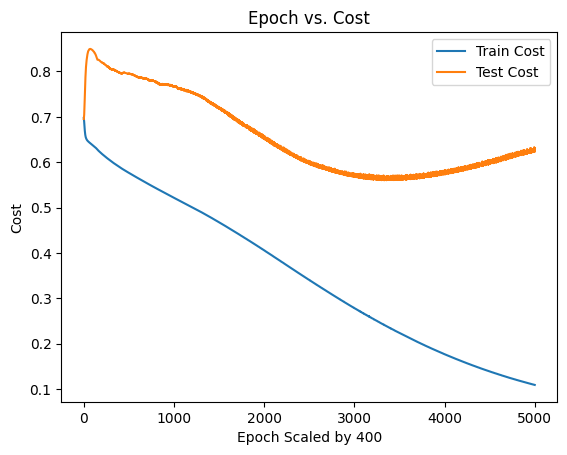

In [48]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="xavier", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: big_random
___________________________________________________________________________________________________


/tmp/ipykernel_9286/4265080186.py:231: RuntimeWarning: divide by zero encountered in divide
  dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))
/tmp/ipykernel_9286/4265080186.py:231: RuntimeWarning: invalid value encountered in divide
  dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))
/tmp/ipykernel_9286/4265080186.py:117: RuntimeWarning: invalid value encountered in multiply
  dZ = dA * A * (1 - A)


Epoch 400; Cost: nan; Duration: 9.58 S
Epoch 800; Cost: nan; Duration: 8.608 S
Epoch 1200; Cost: nan; Duration: 8.736 S
Epoch 1600; Cost: nan; Duration: 8.745 S
Epoch 2000; Cost: nan; Duration: 8.57 S
Epoch 2400; Cost: nan; Duration: 9.024 S
Epoch 2800; Cost: nan; Duration: 8.766 S
Epoch 3200; Cost: nan; Duration: 9.964 S
Epoch 3600; Cost: nan; Duration: 11.946 S
Epoch 4000; Cost: nan; Duration: 10.423 S
Epoch 4400; Cost: nan; Duration: 11.554 S
Epoch 4800; Cost: nan; Duration: 11.22 S
Epoch 5000; Cost: nan; Duration: 0.021 S
________________________________________
Train Accuracy: 0.6555023923444976
Test Accuracy: 0.3400000000000001
________________________________________


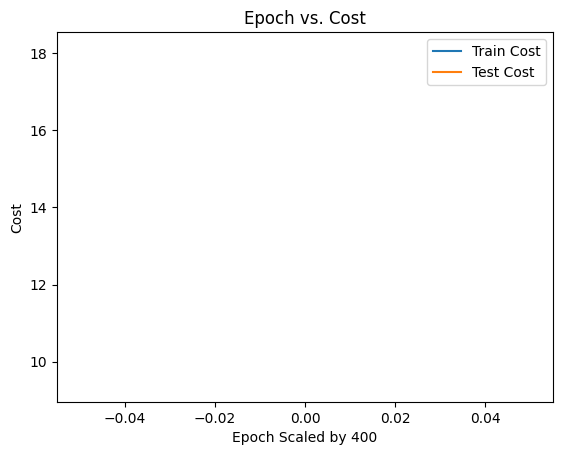

In [49]:
parameters = model(X_train, Y_train, X_test, Y_test, [20, 10, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
                   init="big_random", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: small_random
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6843958389588003; Duration: 9.741 S
Epoch 800; Cost: 0.6772103835128808; Duration: 10.353 S
Epoch 1200; Cost: 0.6713242858389341; Duration: 10.178 S
Epoch 1600; Cost: 0.6664994303693602; Duration: 9.988 S
Epoch 2000; Cost: 0.6625413554994534; Duration: 9.956 S
Epoch 2400; Cost: 0.6592915028973316; Duration: 9.541 S
Epoch 2800; Cost: 0.6566206892724488; Duration: 10.226 S
Epoch 3200; Cost: 0.6544236822409104; Duration: 9.583 S
Epoch 3600; Cost: 0.6526147360360626; Duration: 9.981 S
Epoch 4000; Cost: 0.6511239412052362; Duration: 10.08 S
Epoch 4400; Cost: 0.6498942527614778; Duration: 10.056 S
Epoch 4800; Cost: 0.6488790773684603; Duration: 9.898 S
Epoch 5000; Cost: 0.

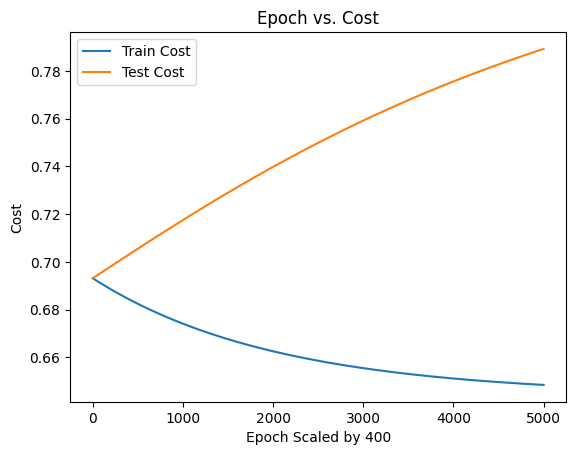

In [50]:
parameters = model(X_train, Y_train, X_test, Y_test, [20, 10, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
                   init="small_random", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: wb_random
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6836996010854092; Duration: 9.162 S
Epoch 800; Cost: 0.6766426001264195; Duration: 8.707 S
Epoch 1200; Cost: 0.6708610119657389; Duration: 8.663 S
Epoch 1600; Cost: 0.6661211812691881; Duration: 9.332 S
Epoch 2000; Cost: 0.6622322995026062; Duration: 9.97 S
Epoch 2400; Cost: 0.6590387861767006; Duration: 10.023 S
Epoch 2800; Cost: 0.6564138777234257; Duration: 10.105 S
Epoch 3200; Cost: 0.6542543040829036; Duration: 10.509 S
Epoch 3600; Cost: 0.6524759092331506; Duration: 10.099 S
Epoch 4000; Cost: 0.6510100711104608; Duration: 10.039 S
Epoch 4400; Cost: 0.6498007873805564; Duration: 9.901 S
Epoch 4800; Cost: 0.6488023095622718; Duration: 10.064 S
Epoch 5000; Cost: 0.64

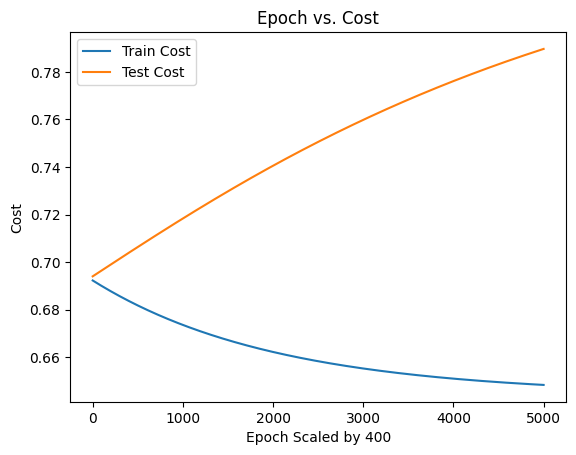

In [51]:
parameters = model(X_train, Y_train, X_test, Y_test, [20, 10, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
                   init="wb_random", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: uniform_random
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6844045234550528; Duration: 8.961 S
Epoch 800; Cost: 0.6772196000644485; Duration: 8.913 S
Epoch 1200; Cost: 0.671333665493167; Duration: 8.528 S
Epoch 1600; Cost: 0.6665087071816055; Duration: 8.751 S
Epoch 2000; Cost: 0.6625503401812605; Duration: 10.228 S
Epoch 2400; Cost: 0.6593000655269058; Duration: 10.835 S
Epoch 2800; Cost: 0.65662874495623; Duration: 12.385 S
Epoch 3200; Cost: 0.6544311896229067; Duration: 12.86 S
Epoch 3600; Cost: 0.6526216736080559; Duration: 11.694 S
Epoch 4000; Cost: 0.651130310096695; Duration: 12.644 S
Epoch 4400; Cost: 0.649900063822413; Duration: 13.088 S
Epoch 4800; Cost: 0.6488843509831853; Duration: 13.597 S
Epoch 5000; Cost: 0.

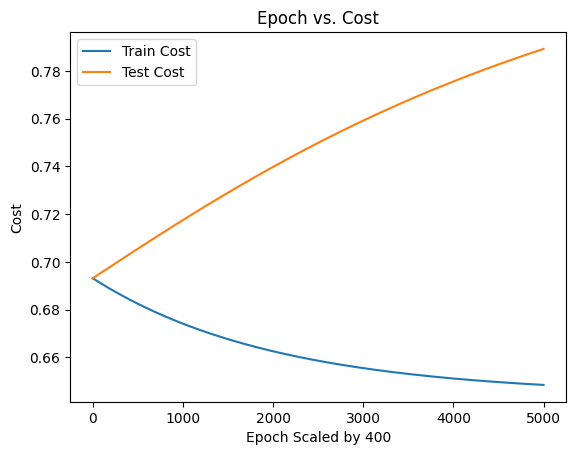

In [52]:
parameters = model(X_train, Y_train, X_test, Y_test, [20, 10, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
                   init="uniform_random", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=400)

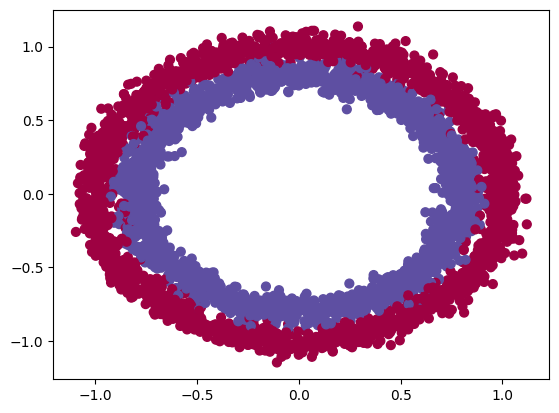

In [57]:
np.random.seed(1)
train_X, train_Y = sklearn.datasets.make_circles(n_samples=4000, noise=.05)
np.random.seed(2)
test_X, test_Y = sklearn.datasets.make_circles(n_samples=400, noise=.05)


plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
train_X = train_X.T
train_Y = train_Y.reshape((1, train_Y.shape[0]))
test_X = test_X.T
test_Y = test_Y.reshape((1, test_Y.shape[0]))

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 3500; Learning Rate: 0.001; Initialization Method: he
___________________________________________________________________________________________________
Epoch 500; Cost: 0.524396841570161; Duration: 8.925 S
Epoch 1000; Cost: 0.4359579490596229; Duration: 8.958 S
Epoch 1500; Cost: 0.3579404838682864; Duration: 9.0 S
Epoch 2000; Cost: 0.28863274534905314; Duration: 8.695 S
Epoch 2500; Cost: 0.22919328108071338; Duration: 8.864 S
Epoch 3000; Cost: 0.18022131125452506; Duration: 9.088 S
Epoch 3500; Cost: 0.13974783887664274; Duration: 9.066 S
________________________________________
Train Accuracy: 0.9856459330143538
Test Accuracy: 0.68
________________________________________


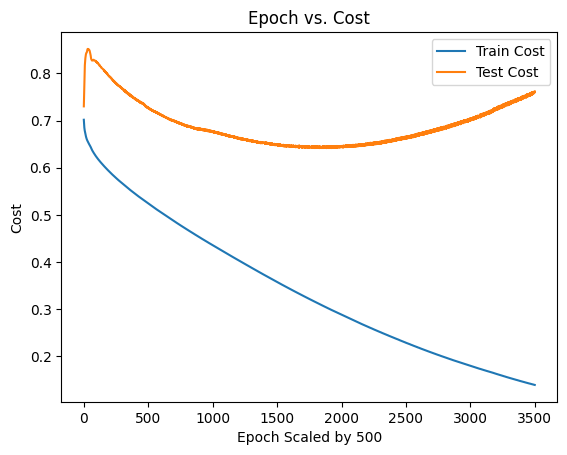

In [61]:
test1 = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
              init="he", num_epochs=3500, learning_rate=1e-3, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 3500; Learning Rate: 0.001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 500; Cost: 0.5630413939311599; Duration: 10.068 S
Epoch 1000; Cost: 0.4875798052123784; Duration: 10.731 S
Epoch 1500; Cost: 0.4117858329236067; Duration: 9.015 S
Epoch 2000; Cost: 0.3353666378584727; Duration: 12.349 S
Epoch 2500; Cost: 0.2639364063345965; Duration: 10.123 S
Epoch 3000; Cost: 0.20725166189476055; Duration: 9.264 S
Epoch 3500; Cost: 0.1628032839813105; Duration: 9.068 S
________________________________________
Train Accuracy: 0.9856459330143538
Test Accuracy: 0.72
________________________________________


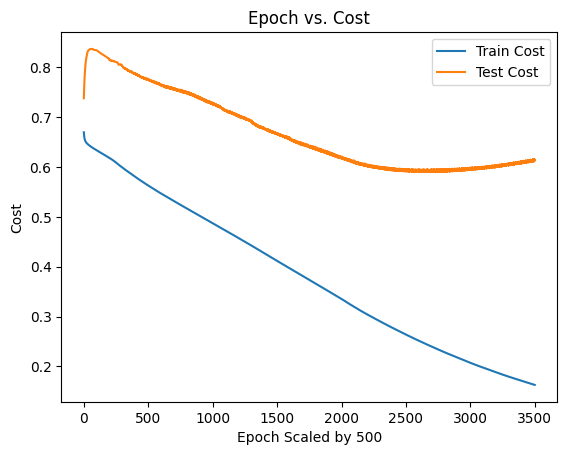

In [62]:
test1 = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
              init="deep", num_epochs=3500, learning_rate=1e-3, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 3500; Learning Rate: 0.001; Initialization Method: xavier
___________________________________________________________________________________________________
Epoch 500; Cost: 0.5747791387564123; Duration: 9.747 S
Epoch 1000; Cost: 0.5004238198327324; Duration: 9.203 S
Epoch 1500; Cost: 0.43490802356015146; Duration: 9.157 S
Epoch 2000; Cost: 0.37646217749193484; Duration: 9.167 S
Epoch 2500; Cost: 0.3241307257423243; Duration: 9.701 S
Epoch 3000; Cost: 0.27649824749121316; Duration: 9.859 S
Epoch 3500; Cost: 0.23496898958456858; Duration: 9.175 S
________________________________________
Train Accuracy: 0.9665071770334925
Test Accuracy: 0.7
________________________________________


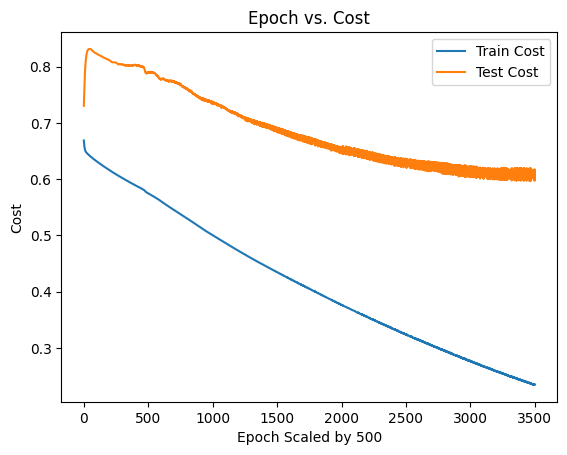

In [63]:
test1 = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
              init="xavier", num_epochs=3500, learning_rate=1e-3, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 6 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 500; Cost: 0.681140594296128; Duration: 9.096 S
Epoch 1000; Cost: 0.6657234705139813; Duration: 9.319 S
Epoch 1500; Cost: 0.6450781394818638; Duration: 8.825 S
Epoch 2000; Cost: 0.624031436908031; Duration: 9.447 S
Epoch 2500; Cost: 0.6008192488168992; Duration: 8.799 S
Epoch 3000; Cost: 0.573727135282175; Duration: 8.735 S
Epoch 3500; Cost: 0.5396778557609359; Duration: 9.058 S
Epoch 4000; Cost: 0.5007210674133653; Duration: 8.856 S
Epoch 4500; Cost: 0.44894062831579945; Duration: 8.841 S
Epoch 5000; Cost: 0.4034800947347676; Duration: 8.897 S
________________________________________
Train Accuracy: 0.894736842105263
Test Accuracy: 0.7
________________________________________


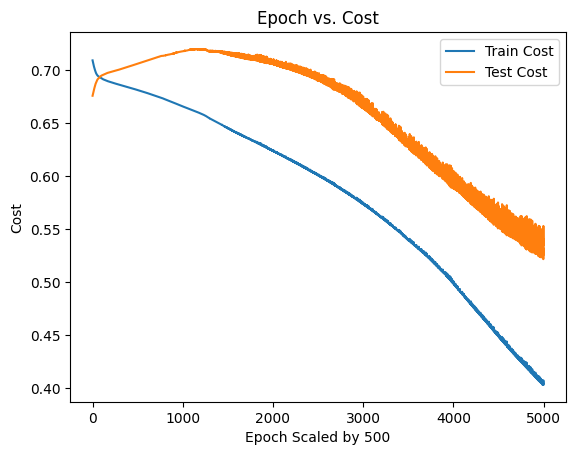

In [64]:
test1 = model(X_train, Y_train, X_test, Y_test, [6, 8, 8, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
              init="deep", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 6 layers; Number of Epochs: 7000; Learning Rate: 0.001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 500; Cost: 0.6206610332547824; Duration: 9.488 S
Epoch 1000; Cost: 0.5706697576215308; Duration: 8.954 S
Epoch 1500; Cost: 0.511986910327715; Duration: 10.498 S
Epoch 2000; Cost: 0.45460212621361873; Duration: 15.805 S
Epoch 2500; Cost: 0.395592250261507; Duration: 11.284 S
Epoch 3000; Cost: 0.3387647338796627; Duration: 9.947 S
Epoch 3500; Cost: 0.29335001774416186; Duration: 9.487 S
Epoch 4000; Cost: 0.25586462686991746; Duration: 10.567 S
Epoch 4500; Cost: 0.2243645995756098; Duration: 9.025 S
Epoch 5000; Cost: 0.20921391956768176; Duration: 8.683 S
Epoch 5500; Cost: 0.1907522917728303; Duration: 9.425 S
Epoch 6000; Cost: 0.17907216852760838; Duration: 9.66 S
Epoch 6500; Cost: 0.16838

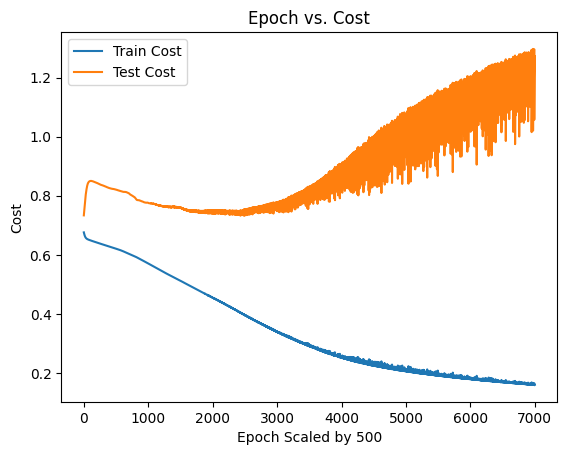

In [65]:
test1 = model(X_train, Y_train, X_test, Y_test, [6, 8, 8, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
              init="deep", num_epochs=7000, learning_rate=1e-3, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 6 layers; Number of Epochs: 8000; Learning Rate: 0.0001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 500; Cost: 0.686464709665784; Duration: 9.713 S
Epoch 1000; Cost: 0.6713123399266616; Duration: 9.351 S
Epoch 1500; Cost: 0.6593536926946317; Duration: 11.323 S
Epoch 2000; Cost: 0.6520401055805994; Duration: 9.395 S
Epoch 2500; Cost: 0.6483202752349406; Duration: 9.731 S
Epoch 3000; Cost: 0.6464394867116198; Duration: 9.018 S
Epoch 3500; Cost: 0.6452284134325841; Duration: 10.595 S
Epoch 4000; Cost: 0.6441981103280837; Duration: 14.691 S
Epoch 4500; Cost: 0.6431853146749099; Duration: 9.226 S
Epoch 5000; Cost: 0.6421399096610511; Duration: 9.636 S
Epoch 5500; Cost: 0.641045261971332; Duration: 9.996 S
Epoch 6000; Cost: 0.6398863650863883; Duration: 9.96 S
Epoch 6500; Cost: 0.6386466041

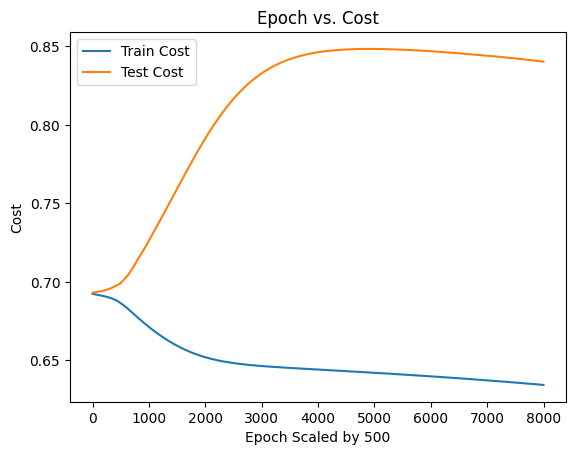

In [66]:
test1 = model(X_train, Y_train, X_test, Y_test, [6, 8, 8, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
              init="deep", num_epochs=8000, learning_rate=1e-4, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 6 layers; Number of Epochs: 5000; Learning Rate: 0.001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 500; Cost: 0.6779692692257934; Duration: 9.659 S
Epoch 1000; Cost: 0.6598288864824252; Duration: 10.577 S
Epoch 1500; Cost: 0.6448684069639229; Duration: 10.383 S
Epoch 2000; Cost: 0.6376864071490954; Duration: 10.622 S
Epoch 2500; Cost: 0.628567707904386; Duration: 8.893 S
Epoch 3000; Cost: 0.6105734434250543; Duration: 9.013 S
Epoch 3500; Cost: 0.5865776551281007; Duration: 8.895 S
Epoch 4000; Cost: 0.5551471801298488; Duration: 8.979 S
Epoch 4500; Cost: 0.5152201280769539; Duration: 9.132 S
Epoch 5000; Cost: 0.4687604346448981; Duration: 9.087 S
________________________________________
Train Accuracy: 0.6555023923444976
Test Accuracy: 0.3400000000000001
_______________________________

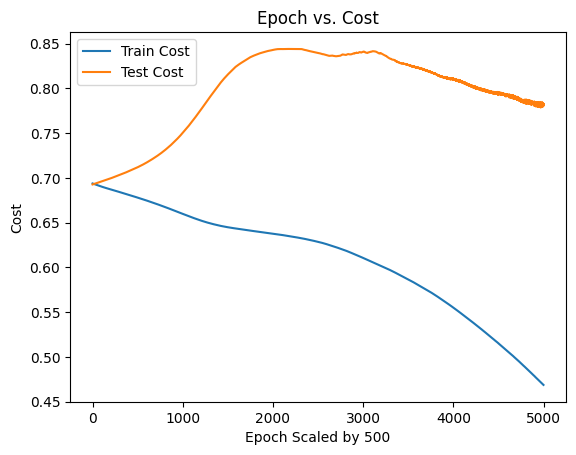

In [67]:
test1 = model(X_train, Y_train, X_test, Y_test, [6, 8, 8, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
              init="deep", num_epochs=5000, learning_rate=1e-3, print_cost=True, epsilon=500)

___________________________________________________________________________________________________
NN_Model with 6 layers; Number of Epochs: 7000; Learning Rate: 0.001; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 500; Cost: 0.6654704157374135; Duration: 9.906 S
Epoch 1000; Cost: 0.6436869581173087; Duration: 9.019 S
Epoch 1500; Cost: 0.6247500081366598; Duration: 10.073 S
Epoch 2000; Cost: 0.5971069039202471; Duration: 9.272 S
Epoch 2500; Cost: 0.5558946933368514; Duration: 8.821 S
Epoch 3000; Cost: 0.49130554015108646; Duration: 8.954 S
Epoch 3500; Cost: 0.40252662220645496; Duration: 9.222 S
Epoch 4000; Cost: 0.2986663280054248; Duration: 9.882 S
Epoch 4500; Cost: 0.24203806340748535; Duration: 9.879 S
Epoch 5000; Cost: 0.2046290514693773; Duration: 10.148 S
Epoch 5500; Cost: 0.17595425621626867; Duration: 9.269 S
Epoch 6000; Cost: 0.1550333349039408; Duration: 9.253 S
Epoch 6500; Cost: 0.13336

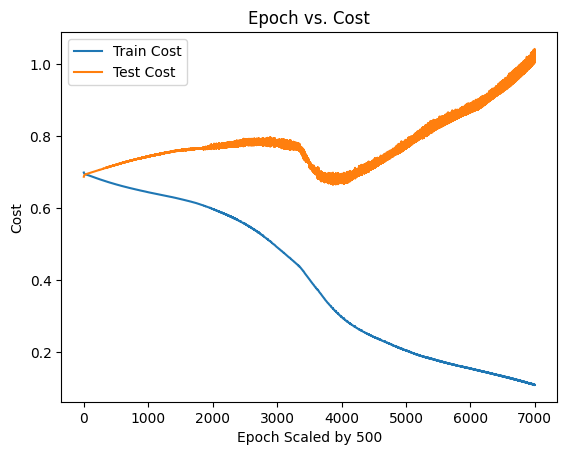

In [68]:
test1 = model(X_train, Y_train, X_test, Y_test, [6, 8, 8, 8, 4], hidden_activation="relu", output_activation="sigmoid", 
              init="deep", num_epochs=7000, learning_rate=1e-3, print_cost=True, epsilon=500)